> # Students Performance Detailed Analysis

![Python](https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white)
![Pandas](https://img.shields.io/badge/Pandas-150458?style=for-the-badge&logo=pandas&logoColor=white)
![scikit-learn](https://img.shields.io/badge/scikit--learn-F7931E?style=for-the-badge&logo=scikit-learn&logoColor=white)
![SciPy](https://img.shields.io/badge/SciPy-0C55A5?style=for-the-badge&logo=scipy&logoColor=white)
![Statsmodels](https://img.shields.io/badge/Statsmodels-00599C?style=for-the-badge&logo=python&logoColor=white)
![Matplotlib](https://img.shields.io/badge/Matplotlib-11557C?style=for-the-badge&logo=python&logoColor=white)
![Seaborn](https://img.shields.io/badge/Seaborn-3776AB?style=for-the-badge&logo=python&logoColor=white)

---

## 0. Project Description
This project is a detailed analysis of a synthetic student performance dataset that contains several features of 1000 students (`gender`, `race/ethnicity`, `parental level of education`, `lunch` & `test preparation course`) and their exam scores (`math score`, `reading score`, `writing score`)

The analysis goes as follows: 
1. Imports & Packages
2. Dataset Analysis & Visualization
3. Feature Engineering
4. Inferential Analysis & Hypothesis Testing
5. Supervised Machine Learning
6. Unsupervised Machine Learning (K-Means Clustering)

---

## 1. Imports & Packages

In [ ]:
# Dataset Analysis and Visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Supervised Machine Learning
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Unsupervised Machine Learning
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

print("All imports ready!")

All imports ready!


## 2. Dataset Analysis & Visualization

In [22]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [23]:
print("Dataset Info:")
df.info()
print("============================")
print("Dataset statistical summary:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
Dataset statistical summary:


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [24]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [25]:
print("Students Gender Distribution:")
print(df["gender"].value_counts(normalize=True).map("{:.1%}".format))
print("===============================")
print("Ethnicity Distribution:")
df["race/ethnicity"].value_counts(normalize=True).map("{:.1%}".format)

Students Gender Distribution:
gender
female    51.8%
male      48.2%
Name: proportion, dtype: object
Ethnicity Distribution:


race/ethnicity
group C    31.9%
group D    26.2%
group B    19.0%
group E    14.0%
group A     8.9%
Name: proportion, dtype: object

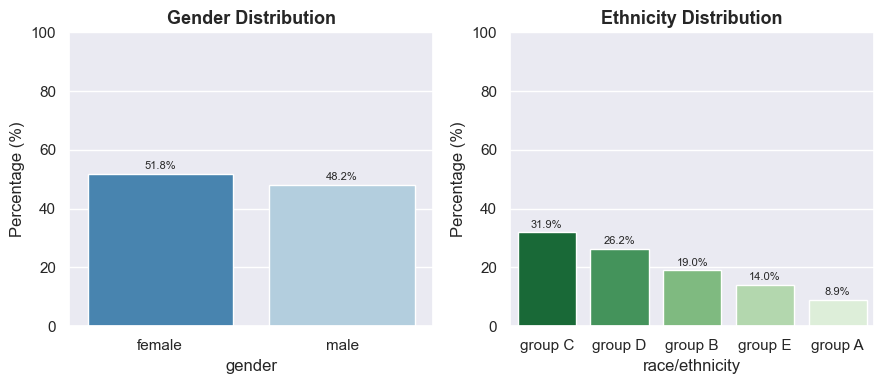

In [26]:
sns.set_theme(style="darkgrid", palette="pastel")
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

gender_pct = df["gender"].value_counts(normalize=True) * 100
race_pct = df["race/ethnicity"].value_counts(normalize=True) * 100

sns.barplot(
    x=gender_pct.index, 
    y=gender_pct.values,
    ax=axes[0],
    hue=gender_pct.index,
    palette="Blues_r",
    legend=False
)

axes[0].set_title("Gender Distribution", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Percentage (%)")
axes[0].set_ylim(0, 100)
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%.1f%%", padding=2, fontsize=8)

sns.barplot(
    x=race_pct.index,
    y=race_pct.values,
    ax=axes[1],
    hue=race_pct.index,
    palette="Greens_r",
    legend=False
)

axes[1].set_title("Ethnicity Distribution", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Percentage (%)")
axes[1].set_ylim(0, 100)
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.1f%%", padding=2, fontsize=8)

plt.tight_layout()
plt.show()

In [27]:
print("Parental Level of Education Distribution:")
print(df["parental level of education"].value_counts(normalize=True).map("{:.1%}".format))
print("===============================")
print("Lunch Distribution:")
df["lunch"].value_counts(normalize=True).map("{:.1%}".format)

Parental Level of Education Distribution:
parental level of education
some college          22.6%
associate's degree    22.2%
high school           19.6%
some high school      17.9%
bachelor's degree     11.8%
master's degree        5.9%
Name: proportion, dtype: object
Lunch Distribution:


lunch
standard        64.5%
free/reduced    35.5%
Name: proportion, dtype: object

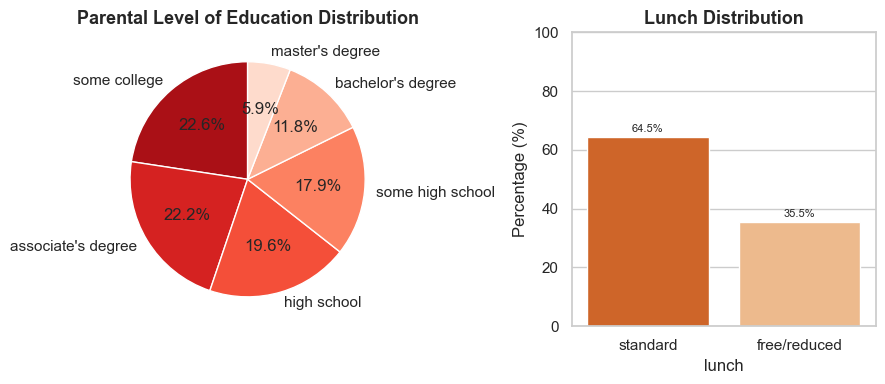

In [28]:
sns.set_theme(style="whitegrid", palette="pastel")
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

gender_pct = df["parental level of education"].value_counts(normalize=True) * 100
race_pct = df["lunch"].value_counts(normalize=True) * 100

axes[0].pie(
    gender_pct.values,
    labels=gender_pct.index,
    autopct="%.1f%%",
    colors=sns.color_palette("Reds_r"),
    startangle=90,
)
axes[0].set_title("Parental Level of Education Distribution", fontsize=13, fontweight="bold")

sns.barplot(
    x=race_pct.index,
    y=race_pct.values,
    ax=axes[1],
    hue=race_pct.index,
    palette="Oranges_r",
    legend=False
)

axes[1].set_title("Lunch Distribution", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Percentage (%)")
axes[1].set_ylim(0, 100)
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.1f%%", padding=2, fontsize=8)

plt.tight_layout()
plt.show()

In [9]:
df.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [29]:
print("Test Preparation Course Distribution:")
print(df["test preparation course"].value_counts(normalize=True).map("{:.1%}".format))
print("===============================")
print("Students Scores Statistical Summary:")
df[["math score", "reading score", "writing score"]].describe()

Test Preparation Course Distribution:
test preparation course
none         64.2%
completed    35.8%
Name: proportion, dtype: object
Students Scores Statistical Summary:


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


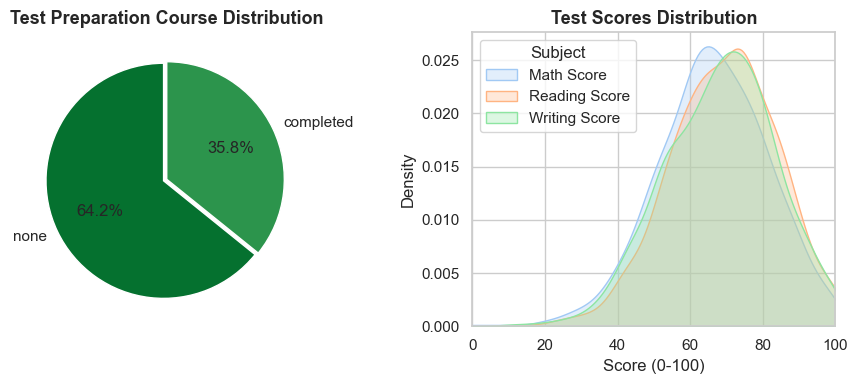

In [30]:
sns.set_theme(style="whitegrid", palette="pastel")
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

course_counts = df["test preparation course"].value_counts()

axes[0].pie(
    course_counts.values,
    labels=course_counts.index,
    autopct="%.1f%%",
    colors=sns.color_palette("Greens_r"),
    startangle=90,
    explode=(0.03, 0),
)
axes[0].set_title("Test Preparation Course Distribution", fontsize=13, fontweight="bold")

score_cols = ["math score", "reading score", "writing score"]
for col in score_cols:
    sns.kdeplot(
        df[col], ax=axes[1], label=col.title(), fill=True, alpha=0.3
    )
axes[1].set_title("Test Scores Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Score (0-100)")
axes[1].set_ylabel("Density")
axes[1].set_xlim(0, 100)
axes[1].legend(title="Subject")

plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [31]:
df["total score"] = df[["math score", "reading score", "writing score"]].sum(axis=1)
df["average score"] = round(df["total score"] / 3, 2)

df["pass_status"] = (df["average score"] >= 50).astype(int)  # 1 for pass, 0 for fail

df["math_verbal_ratio"] = df["math score"] / (df["reading score"] + df["writing score"])

print("Scores and Averages for all Students:")
print(df[["math score", "reading score", "writing score", "total score", "average score"]].head(10))

print("=======================================================================")

print("Pass/Fail Status Distribution:")
print(df["pass_status"].value_counts(normalize=True).map("{:.1%}".format))

print("=======================================================================")

print("Math to Verbal Score Ratio for all Students:")
print(df["math_verbal_ratio"].head())

Scores and Averages for all Students:
   math score  reading score  writing score  total score  average score
0          72             72             74          218          72.67
1          69             90             88          247          82.33
2          90             95             93          278          92.67
3          47             57             44          148          49.33
4          76             78             75          229          76.33
5          71             83             78          232          77.33
6          88             95             92          275          91.67
7          40             43             39          122          40.67
8          64             64             67          195          65.00
9          38             60             50          148          49.33
Pass/Fail Status Distribution:
pass_status
1    89.7%
0    10.3%
Name: proportion, dtype: object
Math to Verbal Score Ratio for all Students:
0    0.493151
1    0.387640


In [32]:
df.shape

(1000, 12)

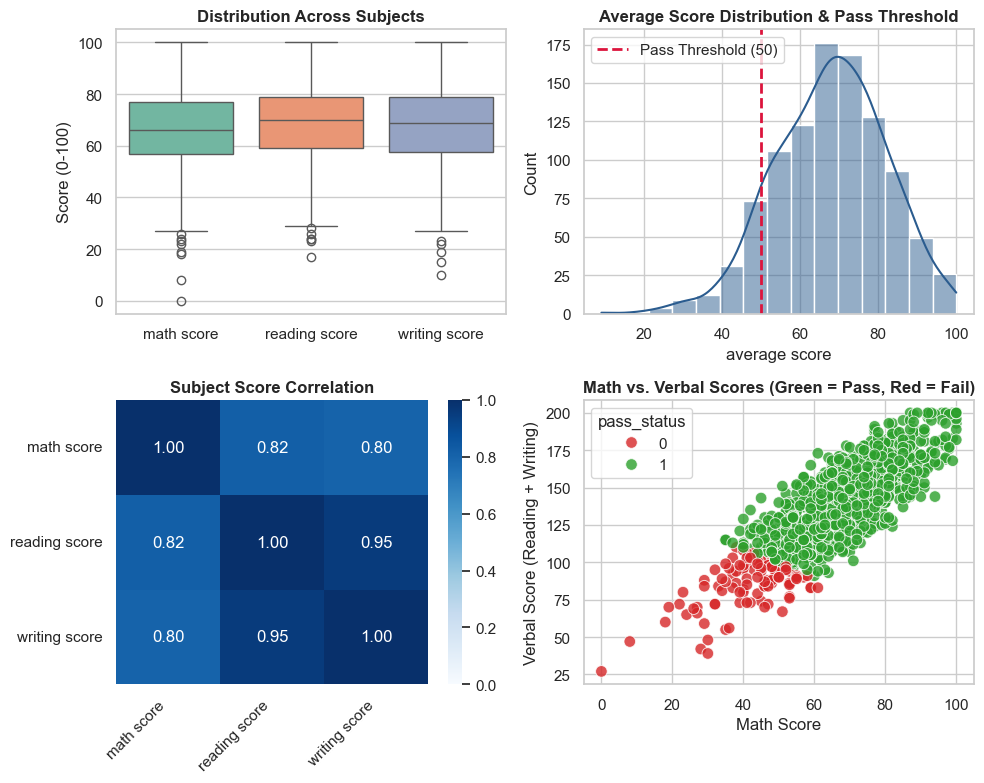

In [33]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.boxplot(
    data=df[["math score", "reading score", "writing score"]], 
    ax=axes[0, 0], 
    palette="Set2"
)
axes[0, 0].set_title("Distribution Across Subjects", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Score (0-100)")

sns.histplot(
    df["average score"],
    kde=True,
    ax=axes[0, 1],
    color="#2b5c8f",
    bins=15
)
axes[0, 1].axvline(50, color="crimson", linestyle="--", linewidth=2, label="Pass Threshold (50)")
axes[0, 1].set_title("Average Score Distribution & Pass Threshold", fontsize=12, fontweight="bold")
axes[0, 1].legend()

corr = df[["math score", "reading score", "writing score"]].corr()
sns.heatmap(
    corr, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues",
    vmin=0.,
    vmax=1, 
    ax=axes[1, 0]
)
axes[1, 0].set_title("Subject Score Correlation", fontsize=12, fontweight="bold")
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45, ha="right")
axes[1, 0].set_yticklabels(axes[1, 0].get_yticklabels(), rotation=0)
 
df["verbal score"] = df["reading score"] + df["writing score"]
sns.scatterplot(
    data=df,
    x="math score",
    y="verbal score",
    hue="pass_status",
    palette={1: "#2ca02c", 0: "#d62728"},
    alpha=0.8,
    s=70,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Math vs. Verbal Scores (Green = Pass, Red = Fail)", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Math Score")
axes[1, 1].set_ylabel("Verbal Score (Reading + Writing)")

plt.tight_layout()
plt.show()

## 4. Inferential Statistics & Hypothesis Testing

In [34]:
prep_completed = df[df["test preparation course"] == "completed"]["average score"]

prep_none = df[df["test preparation course"] == "none"]["average score"]
t_test, p_val_t = stats.ttest_ind(prep_completed, prep_none, equal_var=False)
print(f"T-Test p-value: {p_val_t:.4e}")

anova_model = ols(
    'Q("average score") ~ Q("parental level of education")', data=df
    ).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
print("\nANOVA Table:\n", anova_table)

contingency_table = pd.crosstab(df["lunch"], df["test preparation course"])
chi2, p_val_chi2, dof, ex = stats.chi2_contingency(contingency_table)
print(f"\nChi-Square p-value: {p_val_chi2:.4f}")

T-Test p-value: 4.4221e-17

ANOVA Table:
                                          sum_sq     df          F        PR(>F)
Q("parental level of education")   10420.153338    5.0  10.752938  4.383102e-10
Residual                          192647.487126  994.0        NaN           NaN

Chi-Square p-value: 0.6383


## 5. Supervised Machine Learning

In [35]:
X = df[["gender", "race/ethnicity", "parental level of education", "lunch", "test preparation course"]]
y = df["pass_status"]

categorical_cols = X.columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(drop="first"), categorical_cols)]
)
model_pipeline = Pipeline(
    [
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42)),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.25      0.10      0.14        21
           1       0.90      0.97      0.93       179

    accuracy                           0.88       200
   macro avg       0.58      0.53      0.54       200
weighted avg       0.83      0.88      0.85       200



## 6. Unsupervised Machine Learning

In [36]:
score_cols = ["math score", "reading score", "writing score"]
scaler = StandardScaler()
scaled_scores = scaler.fit_transform(df[score_cols])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(scaled_scores)

print(f"Silhouette Score: {silhouette_score(scaled_scores, df['cluster']):.3f}")
print(f"\nCluster Profiles (Mean Scores):\n")
print(df.groupby("cluster")[score_cols].mean())

Silhouette Score: 0.406

Cluster Profiles (Mean Scores):

         math score  reading score  writing score
cluster                                          
0         65.338600      68.458239      67.821670
1         48.096386      50.670683      48.485944
2         81.714286      85.146104      84.207792


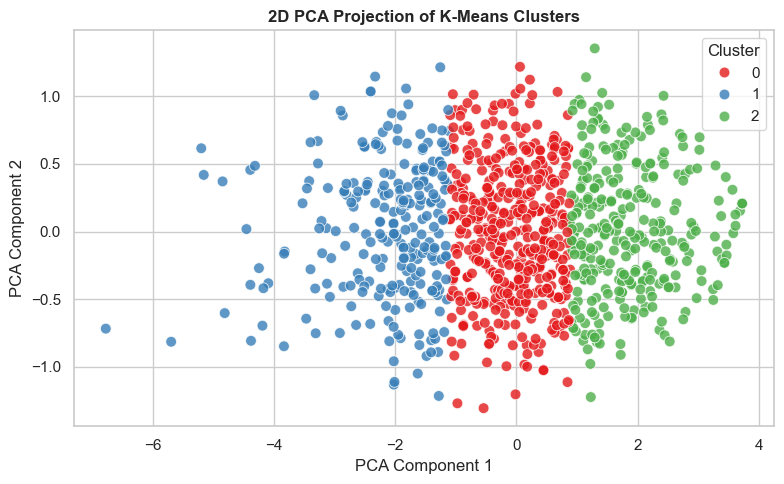

In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(scaled_scores)
df["pca_1"] = pca_coords[:, 0]
df["pca_2"] = pca_coords[:, 1]

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="pca_1",
    y="pca_2",
    hue="cluster",
    palette="Set1",
    s=60,
    alpha=0.8,
)
plt.title("2D PCA Projection of K-Means Clusters", fontweight="bold")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()